# Técnicas avanzadas de Diseño de software

----
## RabbitMQ vs Kafka: Introducción a Sistemas de Mensajería

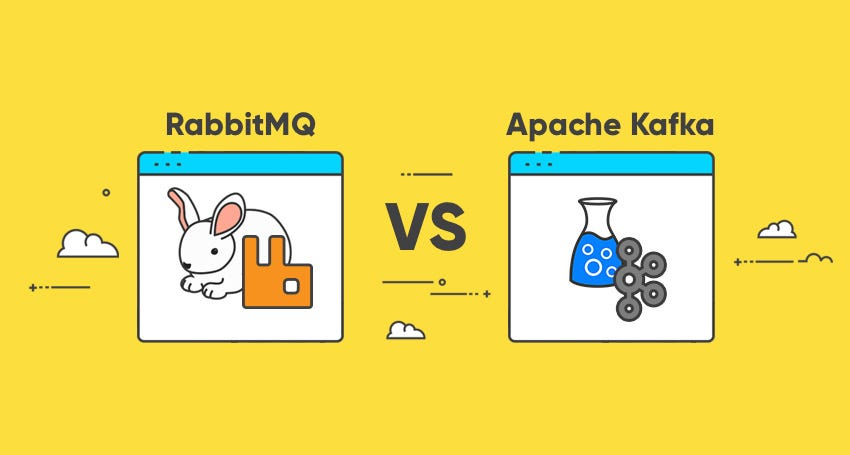

# ¿Qué son los Sistemas de Mensajería?

## Conceptos Fundamentales

- **Message Broker**: Intermediario que acepta y reenvía mensajes
- **Producer**: Aplicación que envía mensajes
- **Consumer**: Aplicación que recibe mensajes
- **Queue/Topic**: Almacenamiento de mensajes

<div align="center">
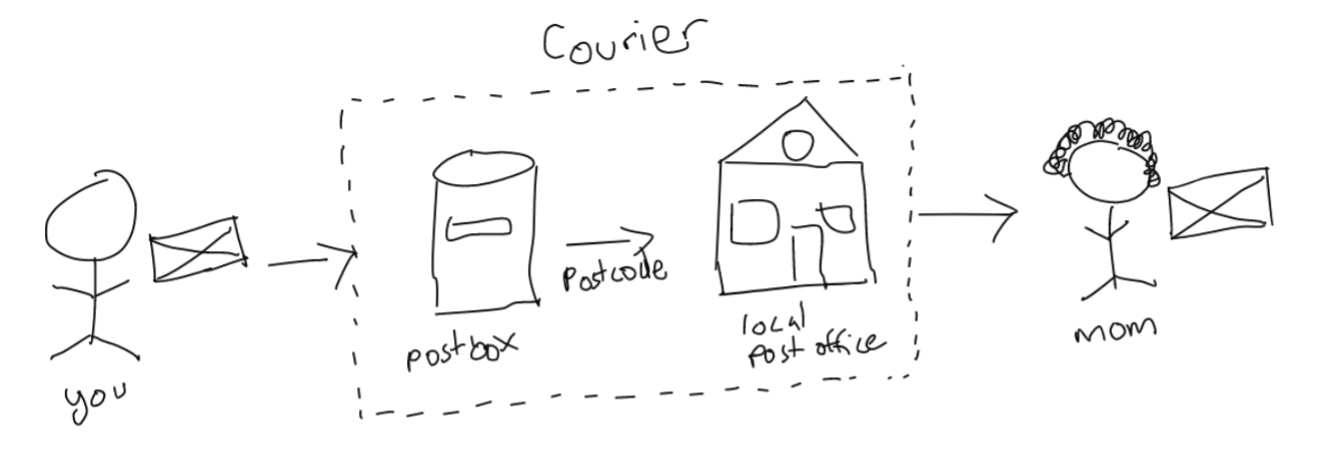
</div>

<div align="center">
<img src="https://www.rabbitmq.com/img/tutorials/python-one.png" style="width: 60% !important">
</div>

> *"You can think about it as a post office: when you put the mail that you want posting in a post box"* - RabbitMQ Tutorial

# RabbitMQ: El Message Broker Maduro

## ¿Qué es RabbitMQ?

- **Creado en 2007** (Erlang)
- **Protocolo AMQP** nativo
- **Enrutamiento flexible** y complejo
- **Garantías de entrega** fuertes
- **Fácil de usar** y operar

<div align="center">
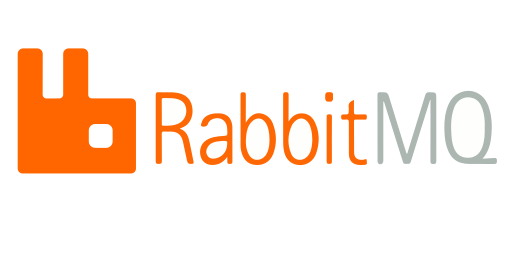
</div>

```python
import pika
connection = pika.BlockingConnection(
    pika.ConnectionParameters('localhost'))
channel = connection.channel()
```

# Apache Kafka: La Plataforma de Streaming

## ¿Qué es Kafka?

- **Creado en 2011** (Scala/Java)
- **Protocolo binario** personalizado
- **Alto throughput** (millones msg/seg)
- **Almacenamiento duradero** con replay
- **Ecosistema completo** de herramientas

<div align="center">
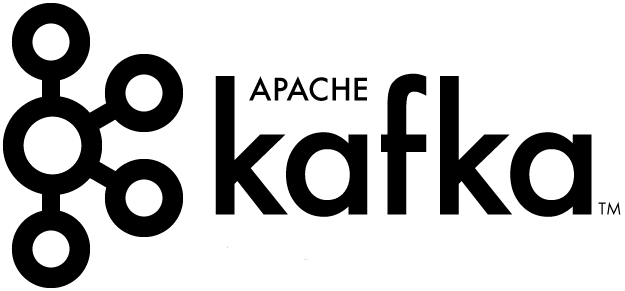
</div>

```python
from kafka import KafkaProducer
producer = KafkaProducer(
    bootstrap_servers=['localhost:9092'],
    value_serializer=lambda v: json.dumps(v).encode())
```

# Arquitecturas: AMQP vs Streaming

## RabbitMQ (AMQP Model)

<div align="center">
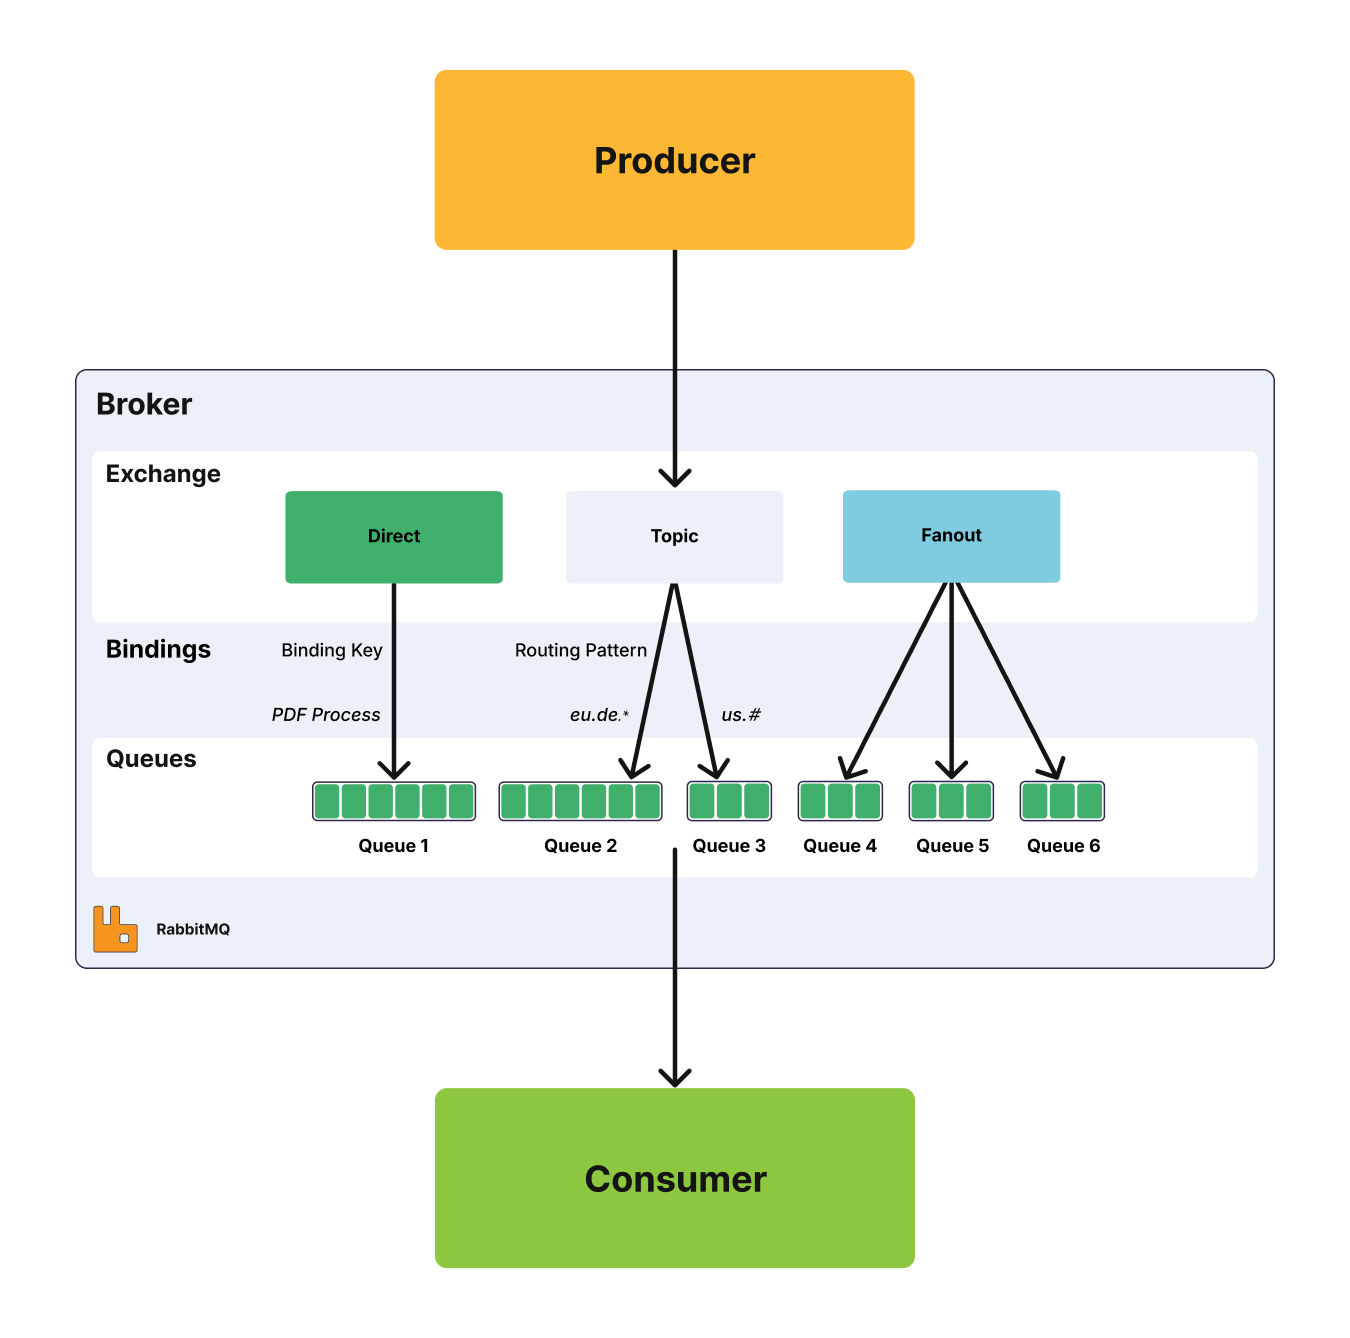
</div>

- **Exchange** → **Queue** → **Consumer**
- Enrutamiento basado en reglas
- Mensajes eliminados tras consumo

# Arquitecturas: AMQP vs Streaming

## Kafka (Streaming Model)

<div align="center">
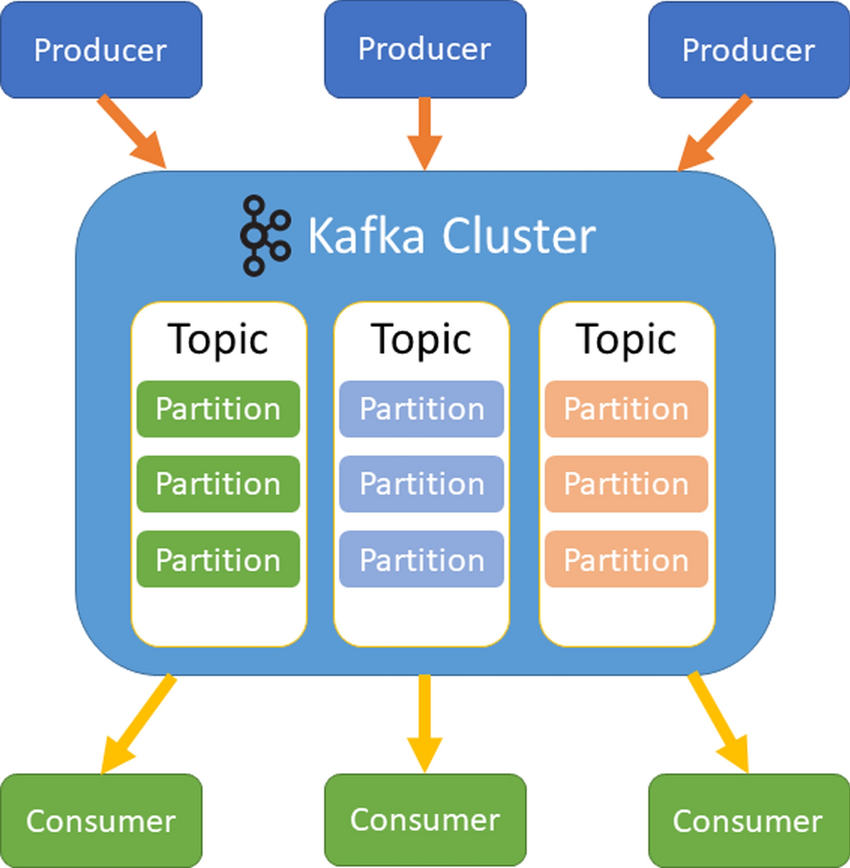
</div>

- **Topic** → **Partitions** → **Consumer Groups**
- Append-only log distribuido
- Mensajes persistentes con TTL

# Primer Ejemplo: Hello World

## RabbitMQ - Enviar Mensaje

```python
#!/usr/bin/env python
import pika

connection = pika.BlockingConnection(
    pika.ConnectionParameters(host='localhost'))
channel = connection.channel()

channel.queue_declare(queue='hello')
channel.basic_publish(exchange='',
                      routing_key='hello',
                      body='Hello World!')
print(" [x] Sent 'Hello World!'")
connection.close()
```

# Primer Ejemplo: Hello World

## RabbitMQ - Recibir Mensaje

```python
def callback(ch, method, properties, body):
    print(f" [x] Received {body.decode()}")

connection = pika.BlockingConnection(
    pika.ConnectionParameters(host='localhost'))
channel = connection.channel()

channel.queue_declare(queue='hello')
channel.basic_consume(queue='hello',
                      on_message_callback=callback,
                      auto_ack=True)

print(' [*] Waiting for messages. To exit press CTRL+C')
channel.start_consuming()
```

# Primer Ejemplo: Hello World

## Kafka - Enviar Mensaje

```python
from kafka import KafkaProducer
import json


producer = KafkaProducer(
    bootstrap_servers=['localhost:9092'],
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

mensaje = {'texto': 'Hello World!', 'timestamp': '2025-06-01T10:00:00Z'}

future = producer.send('hello-topic', value=mensaje)
record_metadata = future.get(timeout=10)
print(f" [x] Sent to {record_metadata.topic}")
producer.close()
```

# Primer Ejemplo: Hello World

## Kafka - Recibir Mensaje

```python
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    'hello-topic',
    bootstrap_servers=['localhost:9092'],
    group_id='mi-grupo',
    value_deserializer=lambda m: json.loads(m.decode('utf-8')),
    auto_offset_reset='earliest'
)

print(' [*] Waiting for messages...')
for mensaje in consumer:
    print(f" [x] Received: {mensaje.value}")
```

# Patrón Pub/Sub: Múltiples Consumidores

## RabbitMQ - Exchange Fanout

```python
# Publisher
channel.exchange_declare(exchange='logs', exchange_type='fanout')
channel.basic_publish(exchange='logs', routing_key='', 
                      body='Sistema iniciado')

# Subscriber
result = channel.queue_declare(queue='', exclusive=True)
queue_name = result.method.queue
channel.queue_bind(exchange='logs', queue=queue_name)
```

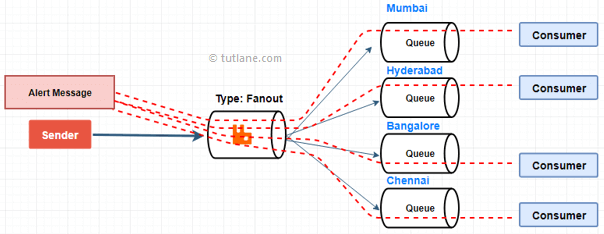

# Patrón Pub/Sub: Múltiples Consumidores

## Kafka - Topic con Consumer Groups

In [ ]:
# Producer (envía a topic)
producer.send('logs-topic', value={'level': 'INFO', 'msg': 'Sistema iniciado'})

# Consumer Group 1 (logging service)
consumer1 = KafkaConsumer('logs-topic', group_id='logging-service')

# Consumer Group 2 (monitoring service)  
consumer2 = KafkaConsumer('logs-topic', group_id='monitoring-service')


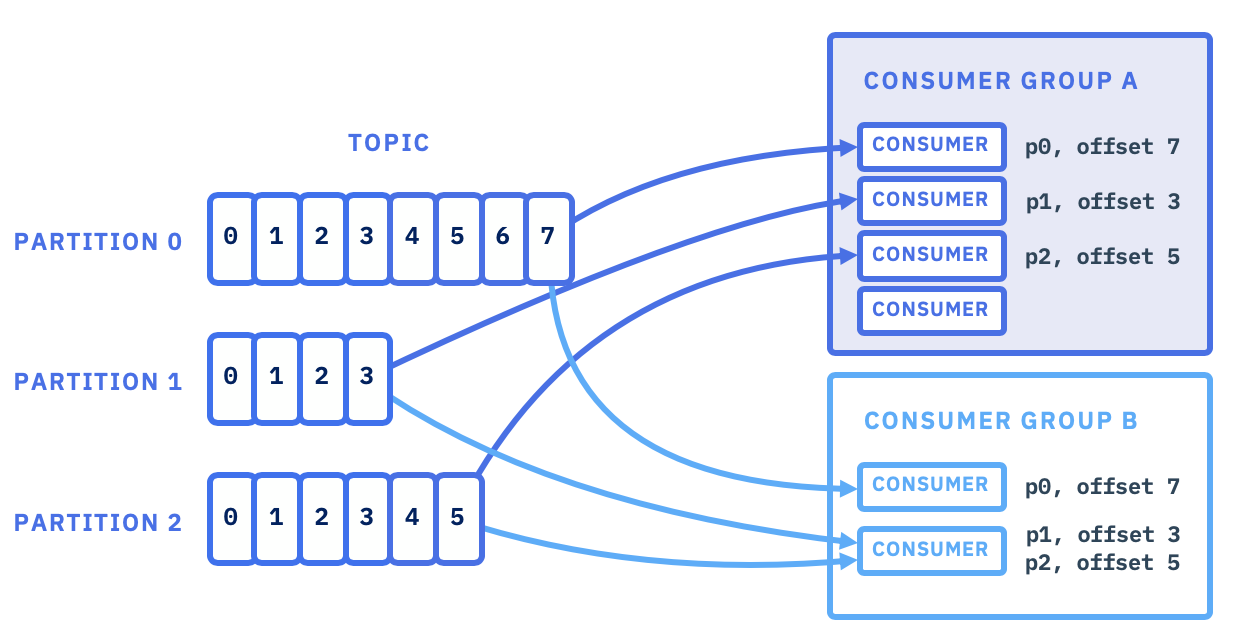

# Work Queues: Distribución de Carga

## RabbitMQ - Múltiples Workers

```python
# WORK QUEUES: Distribución de Trabajo

# === PRODUCER ===
# Cola durable (sobrevive reinicio servidor)
channel.queue_declare(queue='task_queue', durable=True)

# Mensaje persistente (se guarda en disco)
channel.basic_publish(
   exchange='',                    # Exchange por defecto
   routing_key='task_queue',       # → Cola destino
   body='Procesar archivo...',     # Tarea a realizar
   properties=pika.BasicProperties(
       delivery_mode=2             # Persistente
   )
)

# === WORKER ===
# Fair dispatch: solo 1 mensaje por worker activo
channel.basic_qos(prefetch_count=1)

# Consumir con ACK manual (más seguro)
channel.basic_consume(
   queue='task_queue', 
   on_message_callback=callback    # Sin auto_ack!
)

def callback(ch, method, properties, body):
   print(f"Procesando: {body.decode()}")
   # ... hacer trabajo pesado ...
   ch.basic_ack(delivery_tag=method.delivery_tag)  # ✅ Confirmar
```

**Ventaja**: Un mensaje = un worker (garantizado)

# Work Queues: Distribución de Carga

## Kafka - Partitions + Consumer Groups

```python
# KAFKA WORK QUEUES: Distribución por Particiones

# === PRODUCER ===
# Envío con clave para determinar partición
producer.send(
   'tasks-topic',                  # Topic destino
   key=f'task_{task_id}',         # Clave → determina partición
   value={                        # Payload del mensaje
       'task': 'process_file', 
       'file': 'big_file.csv'
   }
)
# Misma clave = misma partición = orden garantizado

# === CONSUMER GROUP ===
# Múltiples workers comparten la carga
consumer = KafkaConsumer(
   'tasks-topic',                 # Topic a consumir
   group_id='workers',            # Grupo de workers
   max_poll_records=1             # Solo 1 mensaje por vez
)

# Cada worker del grupo procesa particiones diferentes
for mensaje in consumer:
   task_data = mensaje.value
   print(f"Worker procesando: {task_data}")
   # ... procesar tarea ...
   # Auto-commit del offset (por defecto)
```

**Ventaja**: Paralelismo por partición + replay capability

**Diferencia clave**: RabbitMQ filtra en el broker, Kafka en el consumer

# Topics: Patrones Complejos

## RabbitMQ - Topic Exchange

In [ ]:
# Routing keys estructurados
routing_keys = [
    'app.user.login',     # app.*.* 
    'app.payment.success', # app.payment.*
    'system.db.error'      # *.*.error
]

# Consumer con wildcards
channel.queue_bind(exchange='topic_logs', queue=queue_name,
                   routing_key='app.*')  # Solo eventos de app


# Topics: Patrones Complejos

## Kafka - Múltiples Topics

In [ ]:
# Diferentes topics por categoría
topics = {
    'user-events': {'action': 'login', 'user': 'juan'},
    'payment-events': {'action': 'success', 'amount': 150},
    'system-events': {'service': 'db', 'status': 'error'}
}

# Consumer de múltiples topics
consumer = KafkaConsumer('user-events', 'payment-events',
                        group_id='analytics')


# Persistencia y Durabilidad

## RabbitMQ: Mensaje Tradicional vs Streams

**Queues Clásicas**

# Mensaje eliminado tras ACK

```python
channel.basic_ack(delivery_tag=method.delivery_tag)
```

- Mensajes desaparecen
- Ideal para tasks

**RabbitMQ Streams**

# Nuevas en v3.9+
# Comportamiento similar a Kafka
# Mensajes persistentes
# Replay disponible


- Append-only log
- Replay capability

# Persistencia y Durabilidad

## Kafka: Siempre Persistente

In [ ]:
# Configurar retención
producer_config = {
    'bootstrap.servers': 'localhost:9092',
    'acks': 'all',  # Esperar todas las réplicas
    'retries': 3
}

# Consumer con offset manual
consumer.commit()  # Confirmar procesamiento


- **Log compaction**: Solo última versión por key
- **Time-based retention**: Retener por tiempo
- **Size-based retention**: Retener por tamaño

# Rendimiento: Números Reales

## Throughput Comparativo

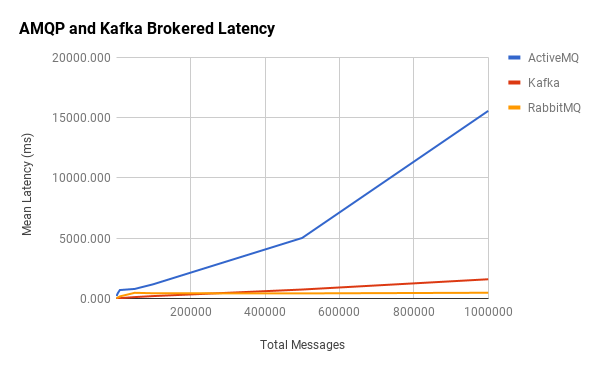

| Aspecto | RabbitMQ | Kafka |
|---------|----------|-------|
| **Msgs/sec** | Miles | Millones |
| **Latencia** | Baja | Media |
| **Persistencia** | Opcional | Por defecto |
| **Memoria** | Eficiente | Java heap |

# Casos de Uso: ¿Cuándo usar qué?

## RabbitMQ es ideal para:

- **Microservicios** comunicación
- **Tasks en background** 
- **Routing complejo** de mensajes
- **Garantías de entrega** estrictas
- **Fácil setup** y operación

## Kafka es ideal para:

- **Streaming** de datos masivos
- **Analytics** en tiempo real
- **Event sourcing** y auditoría
- **Data pipelines** ETL
- **Log aggregation** centralizado

# Seguridad y Operaciones

## RabbitMQ

- **Plugins** para autenticación (LDAP, OAuth2)
- **Management UI** web incluido
- **Clustering** vertical principalmente
- **Fácil troubleshooting**

## Kafka

- **JAAS** para autenticación
- **Herramientas** externas (Confluent, etc.)
- **Clustering** horizontal nativo
- **Más complejo** de operar

# Evolución: RabbitMQ Streams

## La Convergencia

In [ ]:
# RabbitMQ tradicional
channel.queue_declare(queue='classic_queue')

# RabbitMQ Streams (nuevo en v3.9+)
channel.queue_declare(queue='stream_queue', 
                      arguments={'x-queue-type': 'stream'})


> *"Now that RabbitMQ has introduced Streams, this is no longer the case"* - VMware Tanzu

**Resultado**: RabbitMQ puede hacer tanto messaging tradicional como streaming

# Comparativa: Lado a Lado

## Tabla Definitiva

| Característica | RabbitMQ | Kafka |
|---------------|----------|-------|
| **Modelo** | Message Broker | Event Streaming |
| **Protocolo** | AMQP, MQTT, STOMP | Binario/TCP |
| **Routing** | Flexible (exchanges) | Simple (topics) |
| **Persistencia** | Opcional → Streams | Siempre |
| **Replay** | Streams únicamente | Sí |
| **Complejidad** | Baja | Media-Alta |
| **Ecosistema** | Integrado | Extenso (Confluent) |

# Monitoreo y Observabilidad

## RabbitMQ Management

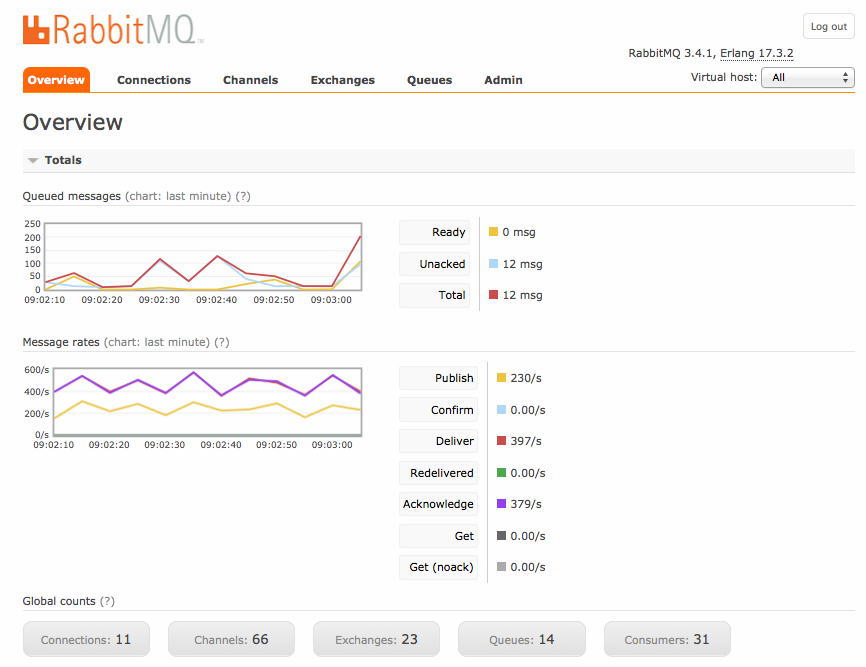

- **Web UI** incluido (puerto 15672)
- **API REST** para métricas
- **Plugins** para monitoring

# Monitoreo y Observabilidad

## Kafka Tooling

- **JMX metrics** 
- **Confluent Control Center**
- **Kafdrop, Kafka Manager**
- **Prometheus + Grafana**

# Decisión: Framework de Evaluación

## Preguntas Clave

1. **¿Necesitas replay?** → Kafka o RabbitMQ Streams
2. **¿Routing complejo?** → RabbitMQ exchanges
3. **¿Millones de msgs/seg?** → Kafka
4. **¿Equipo pequeño?** → RabbitMQ (más simple)
5. **¿Analytics en tiempo real?** → Kafka ecosystem
6. **¿Garantías de entrega?** → RabbitMQ (más fuerte)

# Conclusiones

## Lo que aprendimos

**RabbitMQ**
- Fácil de usar y operar
- Routing flexible
- Ideal para microservicios
- Evoluciona hacia streaming

**Kafka**
- Alto rendimiento
- Ecosistema robusto
- Ideal para big data
- Más complejo pero poderoso

> **No es una competencia**: Son herramientas complementarias para diferentes necesidades

# Próximos Pasos

## ¿Qué hacer ahora?

1. **Prueba los ejemplos** en tu entorno local
2. **Identifica** casos de uso en tu organización  
3. **Experimenta** con ambas tecnologías
4. **Evalúa** según tus necesidades específicas
5. **Considera** RabbitMQ Streams como puente

## Recursos y Referencias

- **RabbitMQ Tutorials**: [rabbitmq.com/tutorials](https://rabbitmq.com/tutorials)
- **Kafka Documentation**: [kafka.apache.org](https://kafka.apache.org)
- **CloudAMQP Blog**: Comparativas detalladas
- **Confluent Resources**: Kafka ecosystem
- **Código de ejemplos**: Disponible en el repositorio

### ¿Preguntas?

*¡Experimenten con ambas tecnologías!*